HEAD OF DATA:     Avg. Session Length  Time on App  Time on Website  Length of Membership  \
0            34.497268    12.655651        39.577668              4.082621   
1            31.926272    11.109461        37.268959              2.664034   
2            33.000915    11.330278        37.110597              4.104543   
3            34.305557    13.717514        36.721283              3.120179   
4            33.330673    12.795189        37.536653              4.446308   

   Yearly Amount Spent  
0           587.951054  
1           392.204933  
2           487.547505  
3           581.852344  
4           599.406092  
SHAPE OF DATA:  (500, 5)
VIF:                 features         VIF
0   Avg. Session Length  601.091686
1       Time on Website  589.301534
2  Length of Membership   13.549347


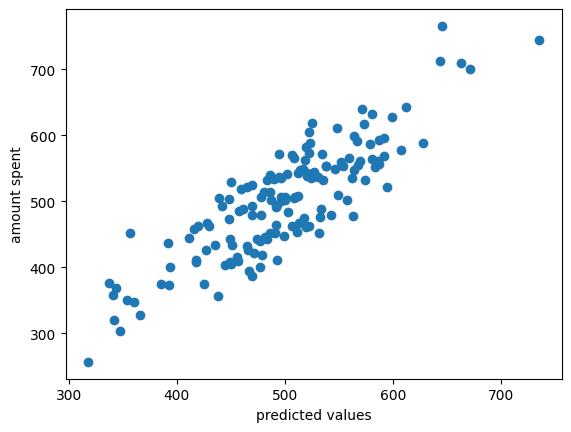

MEAN ABSOLUTE ERROR FOR LINEAR REGRESSION ON WEBSITE:  35.912095937543114
MEAN SQUARED ERROR FOR LINEAR REGRESSION ON WEBSITE:  1877.9889882553714
MEAN SQUARED-ROOTED ERROR FOR LINEAR REGRESSION ON WEBSITE:  43.33577030878038
MEAN ABSOLUTE ERROR FOR LINEAR REGRESSION ON WEBSITE:  40.01492473265332
MEAN SQUARED ERROR FOR LINEAR REGRESSION ON WEBSITE:  2456.5161323512325
MEAN SQUARED-ROOTED ERROR FOR LINEAR REGRESSION ON WEBSITE:  49.56325385153029
RANDOM FOREST PREDICTION OF 31, 27 and 2:  [352.26824897]
VIF:                 features         VIF
0   Avg. Session Length  137.810683
1           Time on App  128.886271
2  Length of Membership   13.577181


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


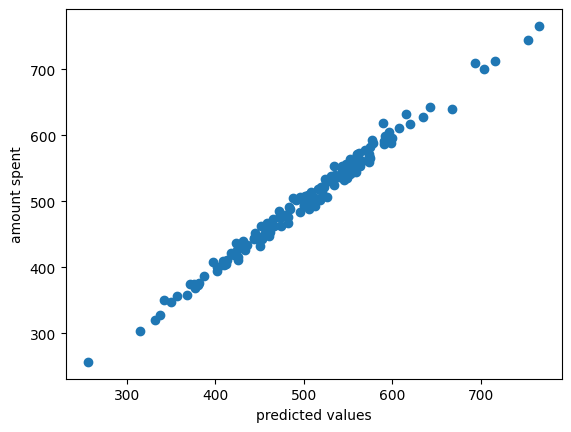

MEAN ABSOLUTE ERROR FOR LINEAR REGRESSION ON APP:  7.236949071999728
MEAN SQUARED ERROR FOR LINEAR REGRESSION ON APP:  80.19544623742955
MEAN SQUARED-ROOTED ERROR FOR LINEAR REGRESSION ON APP:  8.95519102182804
MEAN ABSOLUTE ERROR FOR LINEAR REGRESSION ON APP:  14.201105623826683
MEAN SQUARED ERROR FOR LINEAR REGRESSION ON APP:  393.13017732394337
MEAN SQUARED-ROOTED ERROR FOR LINEAR REGRESSION ON APP:  19.827510618429724
RANDOM FOREST PREDICTION OF 31,11 and 2:  [342.38921795]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
#write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor

data = pd.read_csv("https://confrecordings.ams3.digitaloceanspaces.com/Ecommerce%20Customers.csv")
print("HEAD OF DATA: ", data.head())
print("SHAPE OF DATA: ", data.shape)


################################################################################################################################################################################
X = data[["Avg. Session Length","Time on Website","Length of Membership"]]

y = data["Yearly Amount Spent"]

# create empty dataframe
vif_data = pd.DataFrame()

#Make new column feature
vif_data["features"] = X.columns

#Make an empty list
VIF = []
#calculate variance inflation factor & append in above list
for i in range(0,len(X.columns)):
  vif_value=variance_inflation_factor(X.values , i)
  VIF.append(vif_value)

# calculating VIF for each feature
vif_data["VIF"] = VIF

#display value of vif_data
print("VIF: ",vif_data)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

lr = LinearRegression()
lr.fit(X_train,y_train)

predict_lr = lr.predict(X_test)

plt.scatter(predict_lr,y_test)
plt.xlabel("predicted values")
plt.ylabel("amount spent")
plt.show()

#calculate mean absolute error
print("MEAN ABSOLUTE ERROR FOR LINEAR REGRESSION ON WEBSITE: ", mean_absolute_error(y_test,predict_lr))
mse = mean_squared_error(y_test,predict_lr)
print("MEAN SQUARED ERROR FOR LINEAR REGRESSION ON WEBSITE: ",mse)
print("MEAN SQUARED-ROOTED ERROR FOR LINEAR REGRESSION ON WEBSITE: ", np.sqrt(mse))

from sklearn.metrics import r2_score

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

predict_rf = rf.predict(X_test)

print("MEAN ABSOLUTE ERROR FOR LINEAR REGRESSION ON WEBSITE: ", mean_absolute_error(y_test,predict_rf))
mse = mean_squared_error(y_test,predict_rf)
print("MEAN SQUARED ERROR FOR LINEAR REGRESSION ON WEBSITE: ",mse)
print("MEAN SQUARED-ROOTED ERROR FOR LINEAR REGRESSION ON WEBSITE: ", np.sqrt(mse))

print("RANDOM FOREST PREDICTION OF 31, 27 and 2: ", rf.predict([[31,27,2]]))

#############################################################################################################################################################################

X = data[["Avg. Session Length","Time on App","Length of Membership"]]

y = data["Yearly Amount Spent"]

# create empty dataframe
vif_data = pd.DataFrame()

#Make new column feature
vif_data["features"] = X.columns

#Make an empty list
VIF = []
#calculate variance inflation factor & append in above list
for i in range(0,len(X.columns)):
  vif_value=variance_inflation_factor(X.values , i)
  VIF.append(vif_value)

# calculating VIF for each feature
vif_data["VIF"] = VIF

#display value of vif_data
print("VIF: ",vif_data)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

lr = LinearRegression()
lr.fit(X_train,y_train)

predict_lr = lr.predict(X_test)

plt.scatter(predict_lr,y_test)
plt.xlabel("predicted values")
plt.ylabel("amount spent")
plt.show()

#calculate mean absolute error
print("MEAN ABSOLUTE ERROR FOR LINEAR REGRESSION ON APP: ", mean_absolute_error(y_test,predict_lr))
mse = mean_squared_error(y_test,predict_lr)
print("MEAN SQUARED ERROR FOR LINEAR REGRESSION ON APP: ",mse)
print("MEAN SQUARED-ROOTED ERROR FOR LINEAR REGRESSION ON APP: ", np.sqrt(mse))


rf = RandomForestRegressor()
rf.fit(X_train, y_train)

predict_rf = rf.predict(X_test)

print("MEAN ABSOLUTE ERROR FOR LINEAR REGRESSION ON APP: ", mean_absolute_error(y_test,predict_rf))
mse = mean_squared_error(y_test,predict_rf)
print("MEAN SQUARED ERROR FOR LINEAR REGRESSION ON APP: ",mse)
print("MEAN SQUARED-ROOTED ERROR FOR LINEAR REGRESSION ON APP: ", np.sqrt(mse))

print("RANDOM FOREST PREDICTION OF 31,11 and 2: ", rf.predict([[31,11,2]]))
##################################################################################################################################################################################

#END